In [1]:
import os
import time
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
from torch.amp import GradScaler, autocast
import matplotlib.pyplot as plt

# Device configuration: NVIDIA GPU (Kaggle/Colab) -> Apple Silicon GPU -> CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.backends.cudnn.benchmark = True
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

# Mixed precision only helps on CUDA; MPS and CPU train in float32
use_amp = device.type == 'cuda'
print(f"Accelerating on: {device} (AMP: {use_amp})")

Accelerating on: mps (AMP: False)


In [2]:
# RAF-DB colour dataset laid out as <data_dir>/train/1..7 and <data_dir>/test/1..7
# Uses the Kaggle input when running on Kaggle, otherwise the local copy in ../data/raf-db
kaggle_dir = '/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET'
data_dir = kaggle_dir if os.path.isdir(kaggle_dir) else '../data/raf-db'

# Notice: Grayscale is REMOVED because RAF-DB provides high-quality RGB images
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(f'{data_dir}/{x}', data_transforms[x]) for x in ['train', 'test']}
dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=(x == 'train'), num_workers=2,
                  pin_memory=use_amp, persistent_workers=True)
    for x in ['train', 'test']
}

class_names = image_datasets['train'].classes
# RAF-DB label meanings for folders '1'..'7' (same order as the video inference scripts)
emotion_names = ['Surprise', 'Fear', 'Disgust', 'Happy', 'Sad', 'Anger', 'Neutral']
print(f"Detected Classes: {class_names}")
print(f"Train images: {len(image_datasets['train'])}, Test images: {len(image_datasets['test'])}")

Detected Classes: ['1', '2', '3', '4', '5', '6', '7']
Train images: 12271, Test images: 3068


In [3]:
# Load Pretrained DenseNet-121
model = models.densenet121(weights='DEFAULT')

# DenseNet uses 'classifier' instead of 'fc'
num_ftrs = model.classifier.in_features

# Add Dropout to prevent overfitting, just like we did for ResNet
model.classifier = nn.Sequential(
    nn.Dropout(p=0.5),
    nn.Linear(num_ftrs, len(class_names)) 
)

model = model.to(device)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /Users/user45/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


  0%|          | 0.00/30.8M [00:00<?, ?B/s]

  0%|          | 128k/30.8M [00:00<02:20, 229kB/s]

  1%|          | 256k/30.8M [00:00<01:33, 343kB/s]

  1%|          | 384k/30.8M [00:00<01:06, 479kB/s]

...

 71%|███████   | 21.9M/30.8M [00:05<00:02, 3.25MB/s]

 83%|████████▎ | 25.6M/30.8M [00:06<00:00, 6.27MB/s]

 86%|████████▌ | 26.5M/30.8M [00:06<00:00, 6.35MB/s]

 89%|████████▉ | 27.4M/30.8M [00:06<00:00, 3.72MB/s]

100%|██████████| 30.8M/30.8M [00:06<00:00, 4.68MB/s]

In [4]:
epochs = 12
criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Label smoothing handles noisy labels in datasets

# Upgraded from SGD to AdamW for faster and more stable convergence
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, 
    steps_per_epoch=len(dataloaders['train']), 
    epochs=epochs
)

In [5]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    # With enabled=False (MPS/CPU) the scaler and autocast are no-ops
    scaler = GradScaler(device.type, enabled=use_amp)
    total_steps_limit = num_epochs * len(dataloaders['train'])
    current_step = 0

    history = {'train_loss': [], 'test_loss': [], 'train_acc': [], 'test_acc': []}

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        epoch_start = time.time()
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast(device.type, enabled=use_amp):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()

                        before_step_scale = scaler.get_scale()
                        scaler.step(optimizer)
                        scaler.update()

                        if current_step < total_steps_limit:
                            if scaler.get_scale() >= before_step_scale:
                                scheduler.step()
                                current_step += 1

                running_loss += loss.item() * inputs.size(0)
                # Count as a Python int: MPS does not support float64 tensors
                running_corrects += (preds == labels).sum().item()

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects / len(image_datasets[phase])

            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc)
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
        print(f'Epoch time: {time.time() - epoch_start:.0f}s')

    return model, history

model, history = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/12


train Loss: 1.5082 Acc: 0.4848


test Loss: 1.1123 Acc: 0.6988
Epoch time: 892s
Epoch 2/12


train Loss: 1.0372 Acc: 0.7335


test Loss: 1.0385 Acc: 0.7360
Epoch time: 470s
Epoch 3/12


...

test Loss: 0.7606 Acc: 0.8641
Epoch time: 371s
Epoch 11/12


train Loss: 0.5337 Acc: 0.9734


test Loss: 0.7538 Acc: 0.8706
Epoch time: 378s
Epoch 12/12


train Loss: 0.5140 Acc: 0.9824


test Loss: 0.7512 Acc: 0.8748
Epoch time: 383s


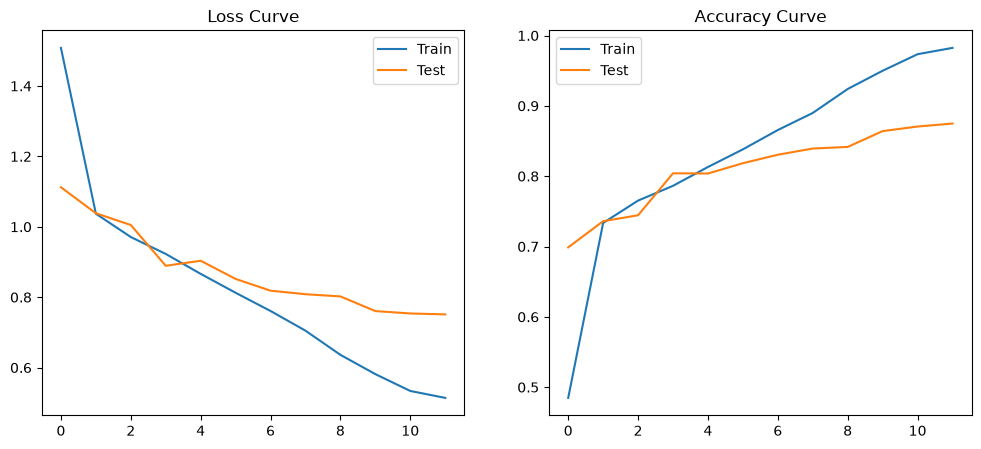

✅ RAF-DB Model saved successfully to 'densenet121_rafdb_final.pth'


In [6]:
# Plot Training History
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train')
plt.plot(history['test_loss'], label='Test')
plt.title('Loss Curve')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train')
plt.plot(history['test_acc'], label='Test')
plt.title('Accuracy Curve')
plt.legend()
plt.show()

# Save the RAF-DB trained model
torch.save(model.state_dict(), 'densenet121_rafdb_final.pth')
print("✅ RAF-DB Model saved successfully to 'densenet121_rafdb_final.pth'")

In [7]:
# Per-class accuracy on the RAF-DB test set
model.eval()
correct = torch.zeros(len(class_names), dtype=torch.long)
total = torch.zeros(len(class_names), dtype=torch.long)

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        preds = model(inputs.to(device)).argmax(1).cpu()
        total += torch.bincount(labels, minlength=len(class_names))
        correct += torch.bincount(labels[preds == labels], minlength=len(class_names))

print(f"Overall test accuracy: {correct.sum().item() / total.sum().item():.4f}\n")
for folder, name, c, t in zip(class_names, emotion_names, correct.tolist(), total.tolist()):
    print(f"{folder} {name:<9} {c / t:.4f}  ({c}/{t})")

Overall test accuracy: 0.8748

1 Surprise  0.8298  (273/329)
2 Fear      0.5676  (42/74)
3 Disgust   0.6375  (102/160)
4 Happy     0.9451  (1120/1185)
5 Sad       0.8619  (412/478)
6 Anger     0.8272  (134/162)
7 Neutral   0.8838  (601/680)
